# Data exploration

In [1]:
import os
import pandas as pd
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

### Load data

In [2]:
def load_ecg_data(data_dir):
    """
    Load ECG data from the specified directory.

    Parameters:
    data_dir (str): Path to the directory containing ECG data files.

    Returns:
    list: A list of tuples, each containing the ECG signal and its corresponding label.
    """
    # Load the labels from REFERENCE.csv
    reference_path = os.path.join(data_dir, 'REFERENCE.csv')
    labels_df = pd.read_csv(reference_path, header=None, names=['record', 'label'])
    labels_dict = dict(zip(labels_df['record'], labels_df['label']))

    ecg_data = []
    for file_name in os.listdir(data_dir):
        if file_name.endswith('.mat'):
            record_name = file_name.replace('.mat', '')
            
            if record_name not in labels_dict:
                continue  # security if one .mat does not have an associated label
            
            file_path = os.path.join(data_dir, file_name)
            mat_data = loadmat(file_path)
            signal = mat_data['val'][0]
            label = labels_dict[record_name]
            
            ecg_data.append((signal, label))
    
    return ecg_data

In [ ]:
ecg_data = load_ecg_data('../data/training2017')
print(f"Number of record loaded : {len(ecg_data)}")
print(f"Example : signal of length {len(ecg_data[0][0])}, label = {ecg_data[0][1]}")

# Check the distribution of classes
labels_only = [label for _, label in ecg_data]
print(pd.Series(labels_only).value_counts())

### ECG examples of four classes

In [ ]:
def ecg_examples_by_class(data, class_labels=None):
    if class_labels is None:
        class_labels = {'N': 'Normal', 'A': 'AF', 'O': 'Other', '~': 'Noisy'}
    
    plt.figure(figsize=(15, 10))
    for i, (code, name) in enumerate(class_labels.items()):
        example = next((signal for signal, label in data if label == code), None)
        if example is None:
            continue
        plt.subplot(len(class_labels), 1, i + 1)
        plt.plot(example)
        plt.title(f'Examples classe : {name} ({code})')
        plt.xlabel('Samples (300 Hz)')
        plt.ylabel('Amplitude')
    
    plt.tight_layout()
    plt.show()

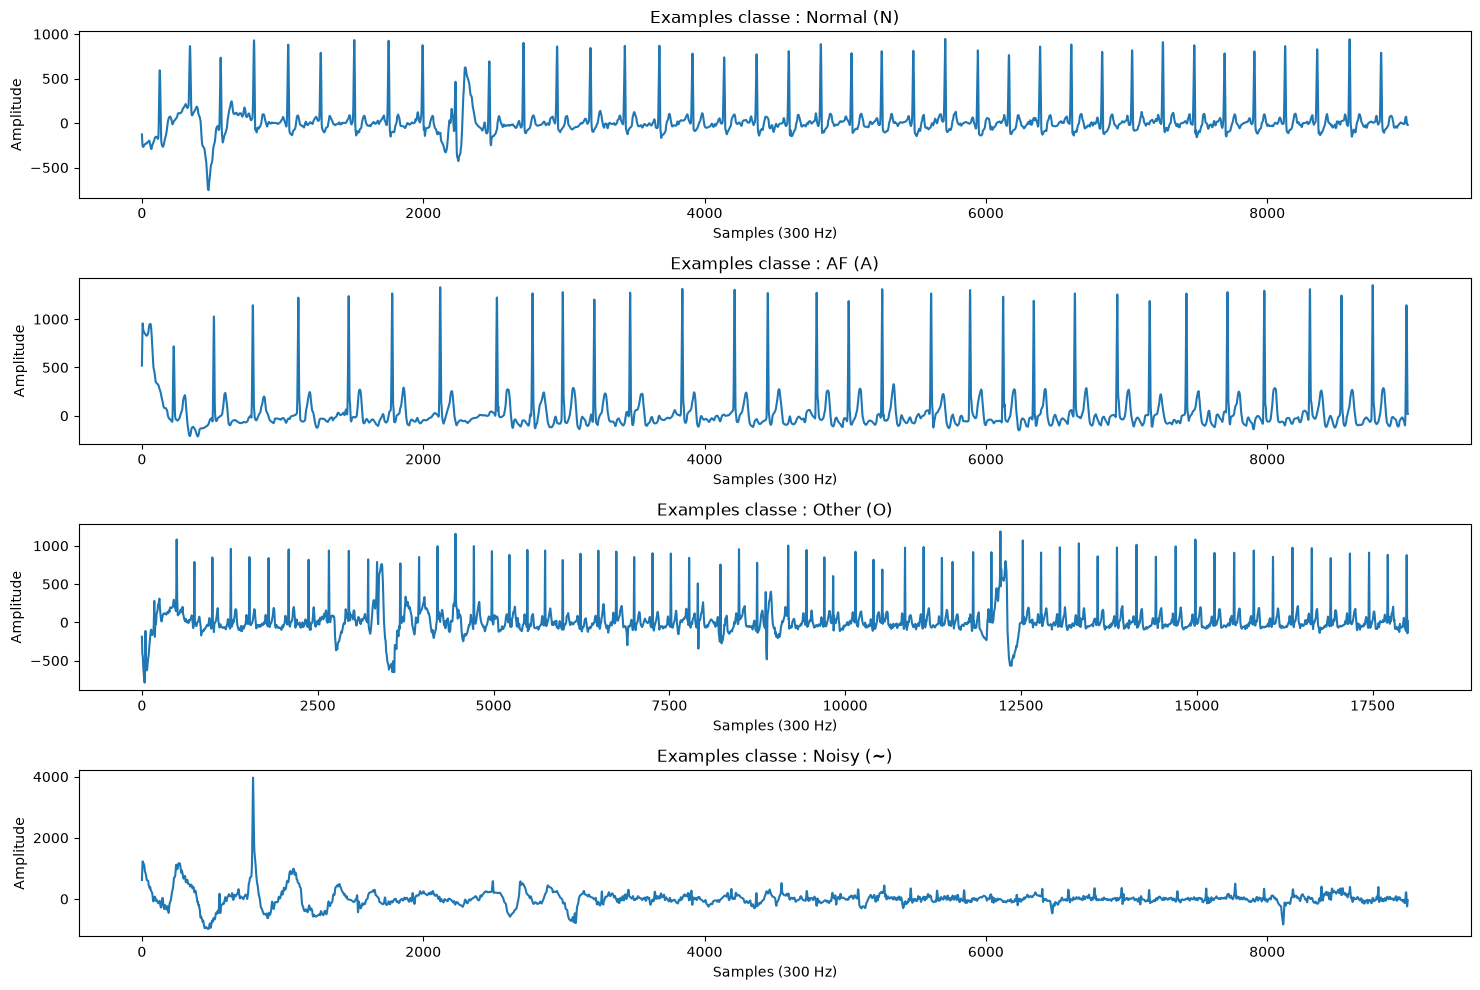

In [ ]:
ecg_examples_by_class(ecg_data)

### Data length histogram distribution 

In [ ]:
def data_length_histogram(data, sampling_rate=300, threshold=9000):
    """
    Plot a histogram of the lengths of the ECG signals.
    """
    lengths = [len(signal) for signal, label in data]
    
    plt.figure(figsize=(10, 6))
    plt.hist(lengths, bins=30, edgecolor='black')
    plt.axvline(threshold, color='red', linestyle='--', 
                label=f'Seuil = {threshold} ({threshold/sampling_rate:.0f}s)')
    plt.title('Histogram of lengths of ECG signals')
    plt.xlabel('Length (number of samples)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
    
    # Statistical summary useful for the report
    print(f"Length min : {min(lengths)} échantillons ({min(lengths)/sampling_rate:.1f}s)")
    print(f"Length max : {max(lengths)} échantillons ({max(lengths)/sampling_rate:.1f}s)")
    print(f"Length median : {sorted(lengths)[len(lengths)//2]} échantillons")

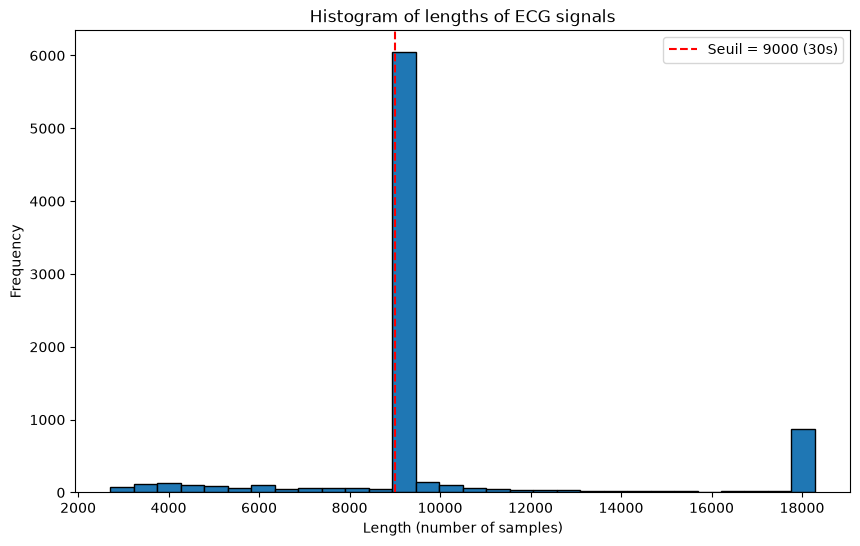

Length min : 2714 échantillons (9.0s)
Length max : 18286 échantillons (61.0s)
Length median : 9000 échantillons


In [ ]:
data_length_histogram(ecg_data)